# 使用 SCSA 进行细胞类型自动注释
单细胞转录组技术可以在一次实验中分析成千上万个细胞，并识别多种组织和物种中的新型细胞类型、细胞状态及其动态变化。围绕组织单细胞转录组图谱的构建，已经发展出较为标准的实验方案和分析流程。

本教程重点介绍如何解释这类数据，以识别细胞类型、细胞状态以及其他具有生物学意义的模式，从而构建带注释的细胞图谱。

论文： [SCSA: A Cell Type Annotation Tool for Single-Cell RNA-seq Data](https://doi.org/10.3389/fgene.2020.00490
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        )

代码： https://github.com/bioinfo-ibms-pumc/SCSA

Colab 复现： https://colab.research.google.com/drive/1BC6hPS0CyBhNu0BYk8evu57-ua1bAS0T?usp=sharing

<div class="admonition warning">
  <p class="admonition-title">注意</p>
  <p>
    SCSA 不适用于稀有细胞类型注释。
  </p>
</div>

![scsa](https://www.frontiersin.org/files/Articles/524690/fgene-11-00490-HTML/image_m/fgene-11-00490-g001.jpg)

In [1]:
import scanpy as sc
print(f'scanpy version:{sc.__version__}')
import omicverse as ov
print(f'omicverse version:{ov.__version__}')
ov.ov_plot_set()

/var/folders/rv/3jnfbs0d6r7d0c5bfj7ft5k00000gn/T/ipykernel_3460/88132617.py:2: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print(f'scanpy version:{sc.__version__}')


scanpy version:1.11.5
omicverse version:2.1.2rc1
🔬 Starting plot initialization...
🧬 Detecting GPU devices…
✅ Apple Silicon MPS detected
    • [MPS] Apple Silicon GPU - Metal Performance Shaders available

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.1.2rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



## 加载数据

该数据集由来自一位健康供体的 3k PBMC 组成，可从 10x Genomics 免费获取（可通过这个[下载链接](http://cf.10xgenomics.com/samples/cell-exp/1.1.0/pbmc3k/pbmc3k_filtered_gene_bc_matrices.tar.gz)或对应的[数据页面](https://support.10xgenomics.com/single-cell-gene-expression/datasets/1.1.0/pbmc3k)下载）。在 Unix 系统中，你可以取消下面代码的注释并运行，以下载和解压数据。最后一行会创建一个用于保存处理后数据的目录。


In [2]:
# !mkdir data
# !wget http://cf.10xgenomics.com/samples/cell-exp/1.1.0/pbmc3k/pbmc3k_filtered_gene_bc_matrices.tar.gz -O data/pbmc3k_filtered_gene_bc_matrices.tar.gz
# !cd data; tar -xzf pbmc3k_filtered_gene_bc_matrices.tar.gz
# !mkdir write

将 count matrix 读入 AnnData 对象。AnnData 提供了多个槽位来存储注释信息和不同形式的数据表示，并且自带基于 HDF5 的文件格式：`.h5ad`。

In [3]:
adata = sc.read_10x_mtx(
    'data/filtered_gene_bc_matrices/hg19/',  # the directory with the `.mtx` file
    var_names='gene_symbols',                # use gene symbols for the variable names (variables-axis index)
    cache=True)                              # write a cache file for faster subsequent reading


## 数据预处理

这里我们使用 `ov.single.scanpy_lazy` 对 scRNA-seq 原始数据进行预处理，流程包括过滤双细胞、按细胞归一化、log1p 转换、提取高变基因以及细胞聚类计算。

如果你希望逐步体验预处理流程，我们也提供了更详细的分步示例，请参考我们的[预处理章节](https://omicverse.readthedocs.io/en/latest/Tutorials-single/t_preprocess/)。

其中原始 counts 保存在 `count` layer 中，原始数据本体可通过 `adata.raw.to_adata()` 访问。

In [4]:
#adata=ov.single.scanpy_lazy(adata)

#quantity control
adata=ov.pp.qc(
    adata,
    tresh={'mito_perc': 0.05, 'nUMIs': 500, 'detected_genes': 250}
)
#normalize and high variable genes (HVGs) calculated
adata=ov.pp.preprocess(adata,mode='shiftlog|pearson',n_HVGs=2000,)

#save the whole genes and filter the non-HVGs
adata.raw = adata
adata = adata[:, adata.var.highly_variable_features]

#scale the adata.X
ov.pp.scale(adata)

#Dimensionality Reduction
ov.pp.pca(adata,layer='scaled',n_pcs=50)

#Neighbourhood graph construction
sc.pp.neighbors(
    adata,
    n_neighbors=15,
    n_pcs=50,
    use_rep='scaled|original|X_pca'
)

#clusters
sc.tl.leiden(adata)

#Dimensionality Reduction for visualization(X_mde=X_umap+GPU)
X_mde = ov.utils.mde(adata.obsm["scaled|original|X_pca"])
if hasattr(X_mde, "detach"):
    X_mde = X_mde.detach().cpu().numpy()
elif hasattr(X_mde, "cpu") and hasattr(X_mde, "numpy"):
    X_mde = X_mde.cpu().numpy()
adata.obsm["X_mde"] = X_mde
adata

🖥️ Using CPU mode for QC...

📊 Step 1: Calculating QC Metrics

   ✓ Gene Family Detection:
   ┌──────────────────────────────┬────────────────────┬────────────────────┐
   │ Gene Family                  │ Genes Found        │ Detection Method   │
   ├──────────────────────────────┼────────────────────┼────────────────────┤
   │ Mitochondrial                │ 13                 │ Auto (MT-)         │
   ├──────────────────────────────┼────────────────────┼────────────────────┤
   │ Ribosomal                    │ 106                │ Auto (RPS/RPL)     │
   ├──────────────────────────────┼────────────────────┼────────────────────┤
   │ Hemoglobin                   │ 13                 │ Auto (regex)       │
   └──────────────────────────────┴────────────────────┴────────────────────┘

   ✓ QC Metrics Summary:
   ┌─────────────────────────┬────────────────────┬─────────────────────────┐
   │ Metric                  │ Mean               │ Range (Min - Max)       │
   ├─────────────────────

AnnData object with n_obs × n_vars = 2605 × 2000
    obs: 'nUMIs', 'mito_perc', 'ribo_perc', 'hb_perc', 'detected_genes', 'cell_complexity', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', 'doublet_score', 'predicted_doublet', 'leiden'
    var: 'gene_ids', 'mt', 'ribo', 'hb', 'n_cells', 'percent_cells', 'robust', 'highly_variable_features', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable'
    uns: 'scrublet', 'status', 'status_args', 'REFERENCE_MANU', 'history_log', 'log1p', 'hvg', 'pca', 'scaled|original|pca_var_ratios', 'scaled|original|cum_sum_eigenvalues', 'neighbors', 'leiden'
    obsm: 'X_pca', 'scaled|original|X_pca', 'X_mde'
    varm: 'PCs', 'scaled|original|pca_loadings'
    layers: 'counts', 'scaled'
    obsp: 'distances', 'connectivities'

## 自动细胞注释

我们基于 `adata` 创建一个 pySCSA 对象，并设置若干参数以获得正确的注释结果。

在常规注释任务中，通常将 `celltype` 设为 `'normal'`，并将 `target` 设为 `'cellmarker'` 或 `'panglaodb'` 来进行细胞类型注释。

而在肿瘤注释任务中，则需要将 `celltype` 设为 `'cancer'`，并将 `target` 设为 `'cancersea'`。

<div class="admonition note">
  <p class="admonition-title">说明</p>
  <p>
    使用 SCSA 进行注释前需要先下载数据库。通常可以自动下载，但在某些网络环境下可能会遇到下载失败的问题。
  </p>
</div>

- 2023 版本（基于 pandas<=1.5.3）：数据库可从 [figshare](https://figshare.com/ndownloader/files/41369037)、[Google Drive](https://drive.google.com/drive/folders/1pqyuCp8mTXDFRGUkX8iDdPAg45JHvheF?usp=sharing) 和 [百度云](https://pan.baidu.com/s/1higlMvx6Y3uOVV_mgwA_mA?pwd=34fv) 下载。
- 2024 版本（基于 pandas>2）：数据库可从 [Google Drive](https://drive.google.com/file/d/1gg2m-edV2Jff8krWovsNb0jxv8A-DFol/view?usp=drive_link) 和 [百度云](https://pan.baidu.com/s/1o7w48z8_5QRlUAjz9auUQg?pwd=j6mp) 下载。

并且你需要将参数 `model_path` 设置为对应数据库文件路径。


数据库构建代码可参考 [scsa_database_create.ipynb](https://github.com/Starlitnightly/omicverse/blob/master/sample/scsa_database_create.ipynb)。感谢 [@fredsamhaak](https://github.com/fredsamhaak) 与 [@H1207953831](https://github.com/H1207953831) 在 issue [#232](https://github.com/Starlitnightly/omicverse/issues/232) 和 [#176](https://github.com/Starlitnightly/omicverse/issues/176) 中的讨论与帮助。


In [5]:
scsa=ov.single.pySCSA(
    adata=adata,
    foldchange=1.5,
    pvalue=0.01,
    celltype='normal',
    target='cellmarker',
    tissue='All',
    model_path='temp/pySCSA_2024_v1_plus.db'                    
)

在前面的聚类步骤中，我们使用的是 leiden 算法，因此这里将聚类类型指定为 leiden。如果你使用的是 louvain，请相应修改该参数。另外，这里会对所有 cluster 进行注释；如果你只想注释部分 cluster，可按 `'[1]'`、`'[1,2,3]'`、`'[...]'` 这样的格式输入。

`rank_rep` 对应 `sc.tl.rank_genes_groups(adata, clustertype, method='wilcoxon')` 的计算过程；如果你的 `adata.uns` 中已经包含 `rank_genes_groups` 结果，则可将 `rank_rep` 设为 `False`。

In [6]:
anno=scsa.cell_anno(
    clustertype='leiden',
    cluster='all',
    rank_rep=True
)

ranking genes
    finished (0:00:00)
...Auto annotate cell
🔍 Version V2.2 [2024/12/18]
📊 DB load: GO_items:47347, Human_GO:3, Mouse_GO:3,
           CellMarkers:82887, CancerSEA:1574, PanglaoDB:24223
           Ensembl_HGNC:61541, Ensembl_Mouse:55414
🔍 Version V2.2 [2024/12/18]
📊 DB load: GO_items:47347, Human_GO:3, Mouse_GO:3,
           CellMarkers:82887, CancerSEA:1574, PanglaoDB:24223
           Ensembl_HGNC:61541, Ensembl_Mouse:55414
📦 Load markers: 70276

🔬 Analyzing 9 clusters...

[1/9]      Cluster 0    │ 75   genes │ 1351 other genes
[2/9]      Cluster 1    │ 154  genes │ 1292 other genes
[3/9]      Cluster 2    │ 581  genes │ 1250 other genes
[4/9]      Cluster 3    │ 128  genes │ 1307 other genes
[5/9]      Cluster 4    │ 81   genes │ 1370 other genes
[6/9]      Cluster 5    │ 908  genes │ 989  other genes
[7/9]      Cluster 6    │ 256  genes │ 1265 other genes
[8/9]      Cluster 7    │ 52   genes │ 1384 other genes
[9/9]      Cluster 8    │ 5    genes │ 1384 other genes

✅ 

我们可以只查看注释质量较好的结果。

In [7]:
scsa.cell_auto_anno(adata,key='scsa_celltype_cellmarker')

...cell type added to scsa_celltype_cellmarker on obs of anndata


我们也可以使用 `panglaodb` 作为 target 来进行细胞类型注释。

In [8]:
scsa=ov.single.pySCSA(
    adata=adata,
    foldchange=1.5,
    pvalue=0.01,
    celltype='normal',
    target='panglaodb',
    tissue='All',
    model_path='temp/pySCSA_2024_v1_plus.db'
)

In [9]:
res=scsa.cell_anno(
    clustertype='leiden',
    cluster='all',
    rank_rep=True
)

ranking genes
    finished (0:00:00)
...Auto annotate cell
🔍 Version V2.2 [2024/12/18]
📊 DB load: GO_items:47347, Human_GO:3, Mouse_GO:3,
           CellMarkers:82887, CancerSEA:1574, PanglaoDB:24223
           Ensembl_HGNC:61541, Ensembl_Mouse:55414
🔍 Version V2.2 [2024/12/18]
📊 DB load: GO_items:47347, Human_GO:3, Mouse_GO:3,
           CellMarkers:82887, CancerSEA:1574, PanglaoDB:24223
           Ensembl_HGNC:61541, Ensembl_Mouse:55414
📦 Load markers: 70276

🔬 Analyzing 9 clusters...

[1/9]      Cluster 0    │ 75   genes │ 632  other genes
[2/9]      Cluster 1    │ 154  genes │ 602  other genes
[3/9]      Cluster 2    │ 581  genes │ 572  other genes
[4/9]      Cluster 3    │ 128  genes │ 592  other genes
[5/9]      Cluster 4    │ 81   genes │ 635  other genes
[6/9]      Cluster 5    │ 908  genes │ 538  other genes
[7/9]      Cluster 6    │ 256  genes │ 586  other genes
[8/9]      Cluster 7    │ 52   genes │ 645  other genes
[9/9]      Cluster 8    │ 5    genes │ 645  other genes

✅ 

我们同样可以只查看注释质量较好的结果。

In [10]:
scsa.cell_anno_print()

Cluster:0	Cell_type:T Cells|T Memory Cells	Z-score:3.72|3.357
Cluster:1	Cell_type:T Cells|T Memory Cells	Z-score:3.539|3.11
Cluster:2	Cell_type:Monocytes|Alveolar Macrophages	Z-score:3.665|2.938
Cluster:3	Cell_type:B Cells Naive|B Cells Memory	Z-score:4.335|3.959
Cluster:4	Cell_type:NK Cells|T Cells	Z-score:2.934|2.508
Cluster:5	Cell_type:Monocytes|Macrophages	Z-score:3.763|2.818
Cluster:6	Cell_type:NK Cells|Gamma Delta T Cells	Z-score:4.052|2.866
Cluster:7	Cell_type:Monocytes|Alveolar Macrophages	Z-score:2.598|2.124
Cluster:8	Cell_type:Decidual Cells|NK Cells	Z-score:1.629|1.629


In [11]:
scsa.cell_auto_anno(adata,key='scsa_celltype_panglaodb')

...cell type added to scsa_celltype_panglaodb on obs of anndata


这里介绍降维可视化函数 `ov.utils.embedding`。它与 `scanpy.pl.embedding` 类似，不同之处在于当设置 `frameon='small'` 时，坐标轴会缩放到左下角，颜色条会缩放到右下角。

- adata: anndata 对象
- basis: 存储在 `adata.obsm` 中、用于展示的嵌入坐标
- color: 需要可视化的 obs/var 信息
- legend_loc: 图例位置；若设为 `None`，会显示在右侧
- frameon: 可以设置为 `small`、`False` 或 `None`
- legend_fontoutline: 图例文字描边宽度
- palette: 用于指定不同类别的颜色。除了 omicverse 的默认调色板外，也可以像下面这样直接传入颜色字典，以获得更稳定的显示效果。

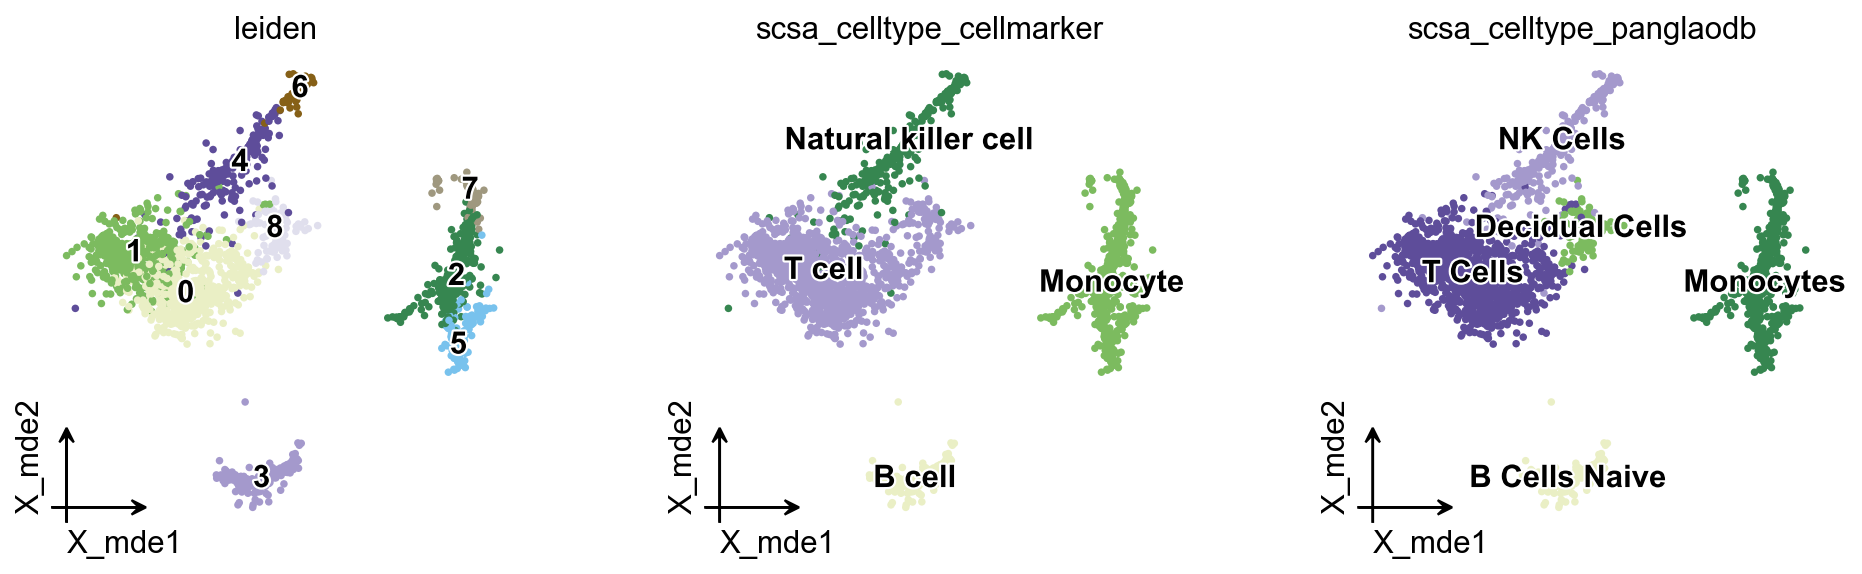

In [12]:
ov.utils.embedding(
    adata,
    basis='X_mde',
    color=['leiden','scsa_celltype_cellmarker','scsa_celltype_panglaodb'],
    legend_loc='on data',
    frameon='small',
    legend_fontoutline=2,
    palette=ov.utils.palette()[9:],
)

如果你想绘制细胞类型比例的堆叠柱状图，首先需要使用 `ov.utils.embedding` 对待比较的分组进行着色，然后再使用 `ov.utils.plot_cellproportion` 指定要展示的分组，即可查看不同组中的细胞比例。

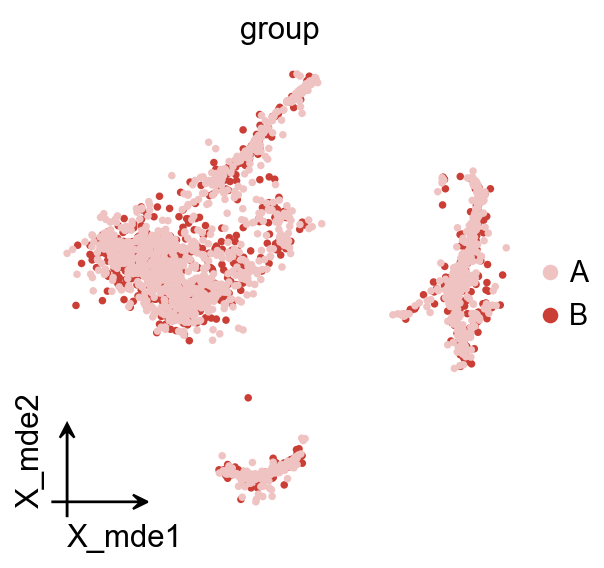

In [13]:
# 随机将前 1000 个细胞标记为 B 组，其余细胞标记为 A 组
adata.obs['group']='A'
adata.obs.loc[adata.obs.index[:1000],'group']='B'
# 着色展示
ov.utils.embedding(
    adata,
    basis='X_mde',
    color=['group'],
    frameon='small',
    legend_fontoutline=2,
    palette={'A': '#F0C3C3', 'B': '#CB3E35'},
)

(<Figure size 160x320 with 1 Axes>,
 <Axes: xlabel='group', ylabel='Cells per Stage'>)

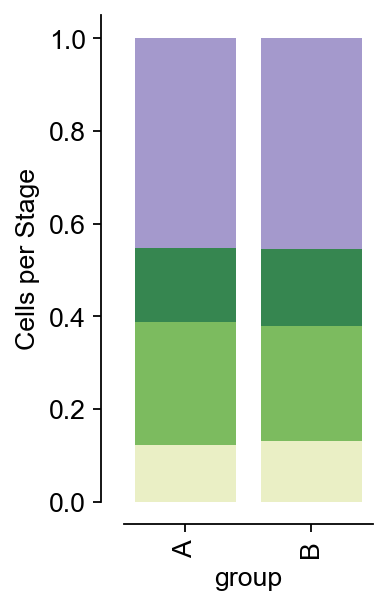

In [14]:
ov.utils.plot_cellproportion(
    adata=adata,
    celltype_clusters='scsa_celltype_cellmarker',
    visual_clusters='group',
    visual_name='group',
    figsize=(2,4)
)

当然，我们还提供了另一种缩略式的嵌入图可视化函数 `ov.utils.plot_embedding_celltype`。

(<Figure size 480x320 with 2 Axes>,
 [<Axes: xlabel='X_mde1', ylabel='X_mde2'>, <Axes: >])

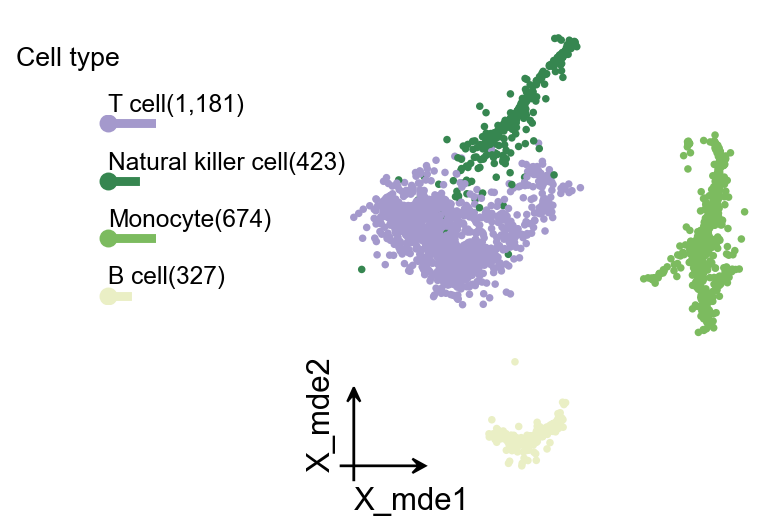

In [15]:
ov.utils.plot_embedding_celltype(
    adata,
    figsize=None,
    basis='X_mde',
    celltype_key='scsa_celltype_cellmarker',
    title='Cell type',
    celltype_range=(2,6),
    embedding_range=(4,10)
)

我们计算了不同组织中每个簇的观测细胞数与期望细胞数之比（Ro/e），以量化每个簇的组织偏好性（Guo et al., 2018; Zhang et al., 2018）。细胞簇与组织组合对应的期望细胞数由卡方检验得到。当某个簇在特定组织中的 Ro/e > 1 时，可以认为该簇在该组织中富集。

Ro/e 相关函数由 `Haihao Zhang` 编写。

In [16]:
roe=ov.utils.roe(
    adata,
    sample_key='group',
    cell_type_key='scsa_celltype_cellmarker'
)

chi2: 0.8694929746430213, dof: 3, pvalue: 0.8327829060823263
P-value is greater than 0.05, there is no statistical significance


Text(0.5, 1.0, 'Ro/e')

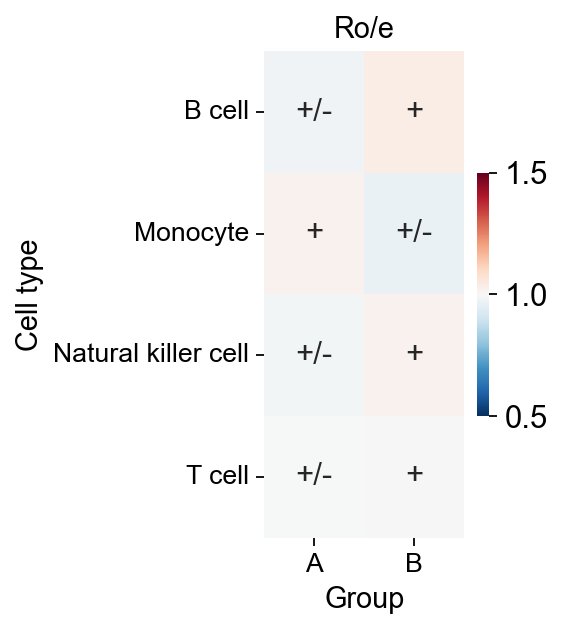

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(2,4))

transformed_roe = roe.copy()
transformed_roe = transformed_roe.applymap(
    lambda x: '+++' if x >= 2 else ('++' if x >= 1.5 else ('+' if x >= 1 else '+/-')))

sns.heatmap(
    roe,
    annot=transformed_roe,
    cmap='RdBu_r',
    fmt='', 
    cbar=True,
    ax=ax,
    vmin=0.5,
    vmax=1.5,
    cbar_kws={'shrink':0.5}
)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.xlabel('Group',fontsize=13)
plt.ylabel('Cell type',fontsize=13)
plt.title('Ro/e',fontsize=13)

## 手动细胞注释

为了比较自动注释结果的准确性，这里我们将使用 marker genes 对各个簇进行手动注释，并将手动注释结果与 pySCSA 的结果进行对比。

首先需要准备一个 marker 基因字典。

In [18]:
res_marker_dict={
    'Megakaryocyte':['ITGA2B','ITGB3'],
    'Dendritic cell':['CLEC10A','IDO1'],
    'Monocyte' :['S100A8','S100A9','LST1',],
    'Macrophage':['CSF1R','CD68'],
    'B cell':['MS4A1','CD79A','MZB1',],
    'NK/NKT cell':['GNLY','KLRD1'],
    'CD8+T cell':['CD8A','CD8B'],
    'Treg':['CD4','CD40LG','IL7R','FOXP3','IL2RA'],
    'CD4+T cell':['PTPRC','CD3D','CD3E'],
}

接着，我们计算每个簇中 marker genes 的表达水平及其表达比例。

    using 'X_pca' with n_pcs = 50
Storing dendrogram info using `.uns['dendrogram_leiden']`
categories: 0, 1, 2, etc.
var_group_labels: Megakaryocyte, Dendritic cell, Monocyte, etc.


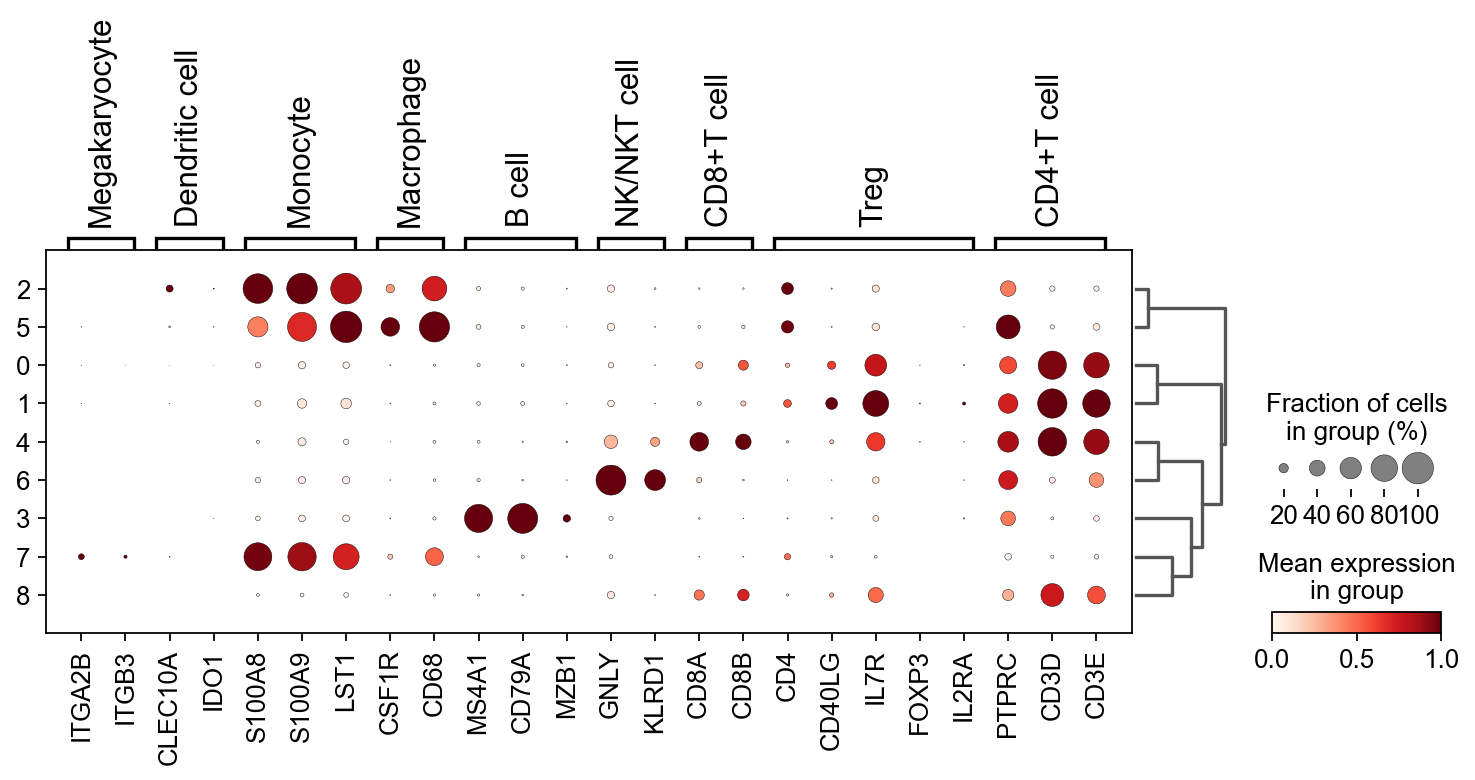

In [19]:
sc.tl.dendrogram(adata,'leiden')
sc.pl.dotplot(
    adata,
    res_marker_dict,
    'leiden', 
    dendrogram=True,
    standard_scale='var'
)

我们也可以使用基于 Marsilea 的新分组热图来展示同一批 marker genes。

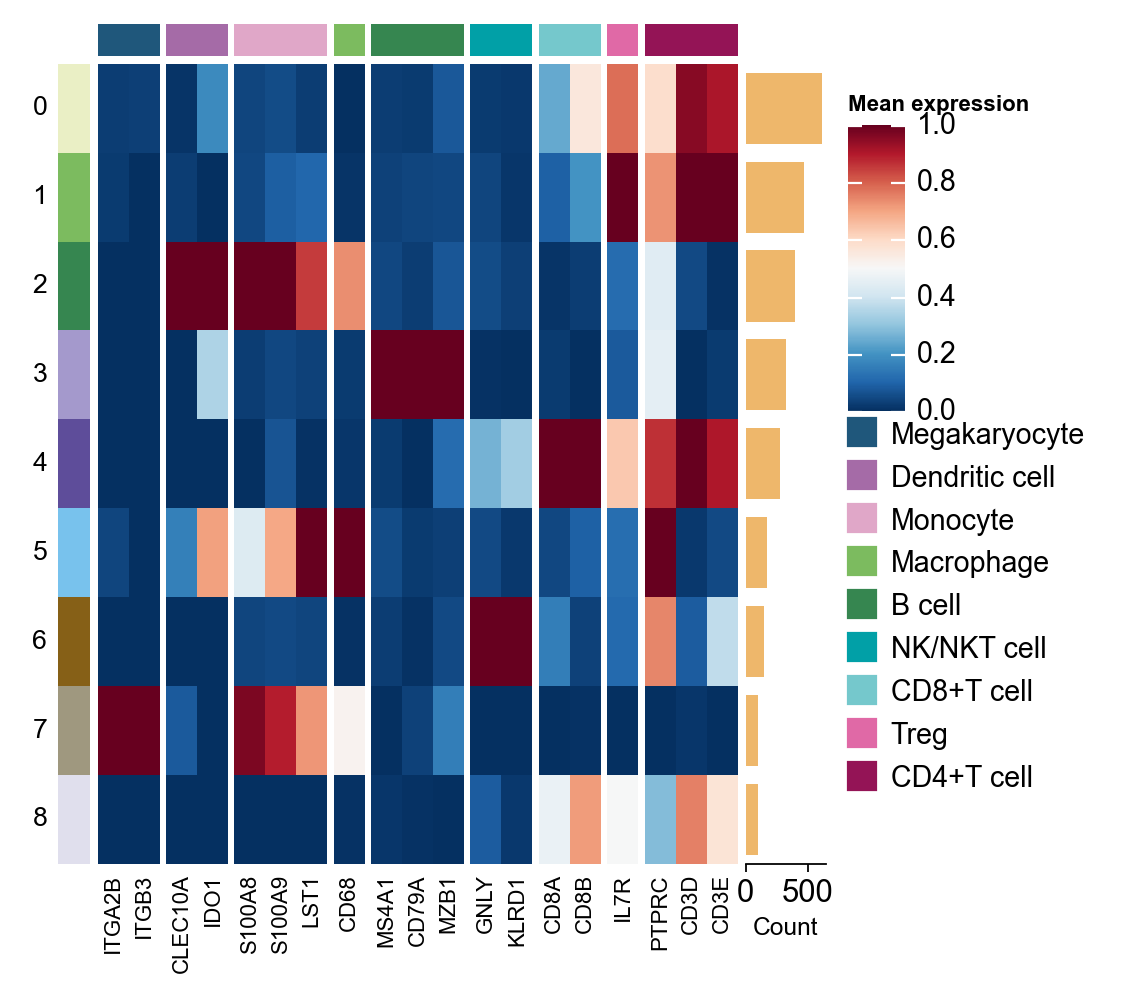

In [20]:
marker_genes_heatmap = {k: v for k, v in res_marker_dict.items() if len(v) > 0}
h = ov.pl.group_heatmap(
    adata,
    var_names=marker_genes_heatmap,
    groupby='leiden',
    figsize=(4, 5),
    standard_scale='var',
    cmap='RdBu_r',
    border=False,
    show=False
)

基于 dotplot 的结果，我们使用 `ov.single.scanpy_cellanno_from_dict` 为每个簇指定名称。

In [21]:
# 创建簇到注释标签的映射字典
cluster2annotation = {
    '0': 'T cell',
    '1': 'T cell',
    '2': 'Monocyte', # Germ-cell(Oid)
    '3': 'B cell',   # Germ-cell(Oid)
    '4': 'T cell',
    '5': 'Macrophage',
    '6': 'NKT cells',
    '7': 'Monocyte',
    '8': 'T cell',
    '9': 'Dendritic cell',
    '10':'Megakaryocyte',
}
ov.single.scanpy_cellanno_from_dict(
    adata,anno_dict=cluster2annotation,
    clustertype='leiden'
)

...cell type added to major_celltype on obs of anndata


## 比较 pySCSA 与手动注释

可以看到，自动注释结果与手动注释结果几乎一致，唯一的差异主要出现在 monocyte 与 macrophage 的区分上。不过在前面的自动注释结果中，pySCSA 也给出了 `monocyte|macrophage` 这样的候选结果，因此可以认为 pySCSA 在 pbmc3k 数据上的表现仍然较好。

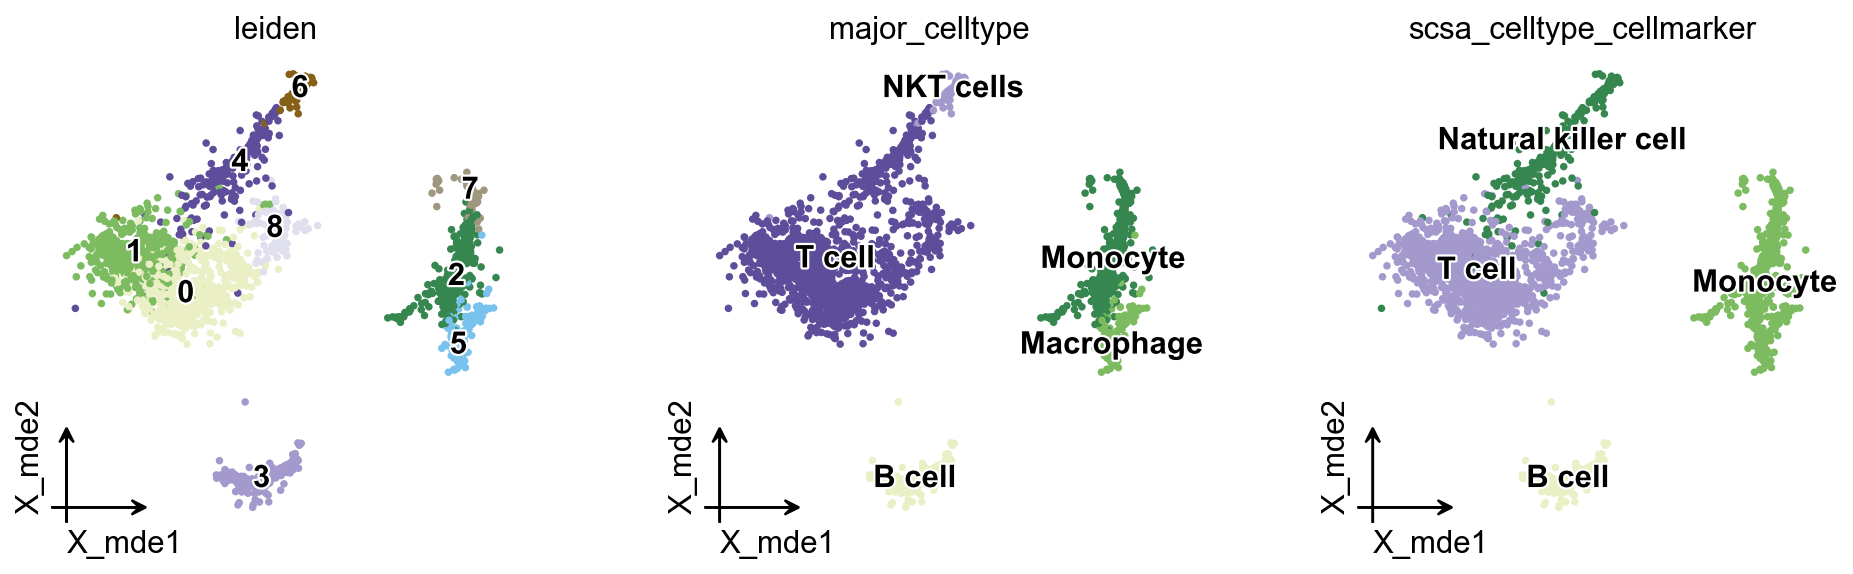

In [22]:
ov.utils.embedding(
    adata,
    basis='X_mde',
    color=['leiden','major_celltype','scsa_celltype_cellmarker'],
    legend_loc='on data',
    frameon='small',
    legend_fontoutline=2,
    palette=ov.utils.palette()[9:],
)

我们也可以使用 `ov.pl.cell_cor_heatmap` 来比较手动注释结果与 pySCSA 自动注释结果之间的表达相似性。

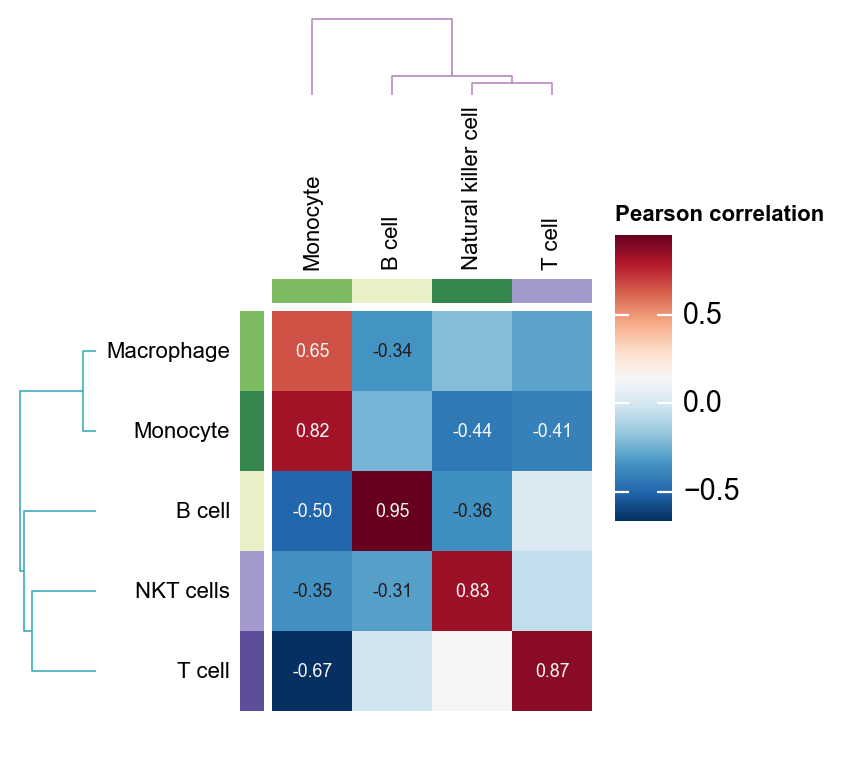

In [23]:
cell_cor_h = ov.pl.cell_cor_heatmap(
    adata,
    group_by='major_celltype',
    ref_adata=adata,
    ref_group_by='scsa_celltype_cellmarker',
    method='pearson',
    standard_scale='var',
    cmap='RdBu_r',
    figsize=(2, 2.5),
    row_cluster=True,
    col_cluster=True,
    show_values=True,
    value_cutoff=0.3,
    border=False,
    show=False,
)

我们可以使用 `get_celltype_marker` 获取每种细胞类型对应的 marker genes。

In [24]:
marker_dict=ov.single.get_celltype_marker(adata,clustertype='scsa_celltype_cellmarker')
marker_dict.keys()

...get cell type marker
ranking genes
    finished (0:00:00)


dict_keys(['B cell', 'Monocyte', 'Natural killer cell', 'T cell'])

In [25]:
marker_dict['B cell']

['CD37',
 'HLA-DPB1',
 'HLA-DQA1',
 'CD74',
 'MS4A1',
 'HLA-DRB1',
 'HLA-DRA',
 'CD79B',
 'HLA-DQB1',
 'CD79A']

## 数据库中的组织名称

如果需要对特定组织中的细胞类型进行注释，可以使用 `get_model_tissue` 查询数据库中可用的组织名称。

In [26]:
scsa.get_model_tissue()

🔍 Version V2.2 [2024/12/18]
📊 DB load: GO_items:47347, Human_GO:3, Mouse_GO:3,
           CellMarkers:82887, CancerSEA:1574, PanglaoDB:24223
           Ensembl_HGNC:61541, Ensembl_Mouse:55414
########################################################################################################################
------------------------------------------------------------------------------------------------------------------------
Species:Human      Num:298       
------------------------------------------------------------------------------------------------------------------------
  1: Abdomen                              2: Abdominal adipose tissue             3: Abdominal fat pad                  
  4: Acinus                               5: Adipose tissue                       6: Adrenal gland                      
  7: Adventitia                           8: Airway                               9: Airway epithelium                  
 10: Allocortex                          11: Alv